# **Song Popularity Analysis**
Darian Tocci and Marissa Vagnoni

Link to Our Website: https://dartocc.github.io/

In [27]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import io

file_path = '/content/drive/MyDrive/song_data.csv'
# Read the CSV
df = pd.read_csv(file_path)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Project Goals**

We aim to analyze datasets pertaining to the popularity of music and the different characteristics of a song that correlate to its popularity, with the intention of finding some common themes amongst the popularity of music and the characteristics of their production. Currently, we have found and are hoping to use three datasets that measure music popularity, multiple elements of a song, and listener preferences. The dataset we will mainly be working with for this milestone is a [Song Popularity Dataset](https://www.kaggle.com/datasets/yasserh/song-popularity-dataset). This dataset contains 13,070 songs and a variety of song elements for each song pertaining to its popularity, basic musical structure, and audio components. In addition to this dataset, we also plan to use the following two Spotify datasets:
[Most Streamed Spotify Songs (2024)](https://www.kaggle.com/datasets/nelgiriyewithana/most-streamed-spotify-songs-2024).  This is a dataset with over 4,600 tracks and fields such track name, artist, album, release date, streaming counts across multiple different platforms, and playlist reach.
 Additionally, High Popularity Spotify Data (the link is currently down), which is a dataset with detailed features of the tracks like tempo, energy, valence, danceability, etc. for both more modern pop and classic rock hits.

**Collaboration Plan:**
Aside from breaks and traveling that will require zoom meetings, we will mainly be working on this project in person about 1-2 times a week using a shared google colab and pushing our changes to a shared GitHub respository. Additionally, we will communicate frequently over text with any brief ideas or concerns that need to be addresses in the moment. Lastly, we have created a progress timeline based on the rubric from our syllabus to ensure we are staying on track with each project milestone.



**Research Questions**

*   How do musical elements correlate with track popularity?

*   Do recent songs differ from older, more classic music in ways that might explain their streaming success?


*   Which artists consistently dominate Spotify playlists, and what common
traits do their songs share?

# **Data Tidying**

This dataset is fairly tidy as is. There are a few alterations and data table combinations we could make to aid in analyzation.

In [28]:
df.dtypes

,0
song_name,object
song_popularity,int64
song_duration_ms,int64
acousticness,float64
danceability,float64
energy,float64
instrumentalness,float64
key,int64
liveness,float64
loudness,float64


All columns are assigned the correct type besides audio_mode. This should be assigned as an object as it is categorical data.

Additionally, we will assign a string to each numerical label to clarify the meanings of these values. 1 represents a song in major and 0 represents a song in minor.

In [29]:
df['audio_mode'] = df['audio_mode'].map({1: 'major', 0: 'minor'})
df['audio_mode'] = df['audio_mode'].astype(str)

**Table 1: Basic Musical Data**

This first table groups together basic musical elements that pertain to the structural attributes of each song.

Additionally we are going to map audio mode so that the numeric values are

In [30]:
song_basic_data = df[['song_name', 'song_duration_ms', 'key', 'audio_mode', 'tempo', 'time_signature']].copy()
song_basic_data.head()

,song_name,song_duration_ms,key,audio_mode,tempo,time_signature
0,Boulevard of Broken Dreams,262333,8,major,167.060,4
1,In The End,216933,3,minor,105.256,4
2,Seven Nation Army,231733,0,major,123.881,4
3,By The Way,216933,0,major,122.444,4
4,How You Remind Me,223826,10,major,172.011,4


**Table 2: Popularity**

Tracks how well each song performs. A key aspect of song popularity is that it is not being used as a ranking. The popularity value given to each song is a score given to each song based on listener engagement from a streaming service.

In [31]:
popularity_table = df[['song_name', 'song_popularity']].copy()
popularity_table.head()

,song_name,song_popularity
0,Boulevard of Broken Dreams,73
1,In The End,66
2,Seven Nation Army,76
3,By The Way,74
4,How You Remind Me,56


**Table 3: Audio Features**

Descriptive variables from an audio analysis.

In [32]:
audio_features = df[['song_name', 'acousticness', 'danceability', 'energy',
                     'instrumentalness', 'liveness', 'loudness', 'speechiness', 'audio_valence']].copy()
audio_features.head()

,song_name,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,audio_valence
0,Boulevard of Broken Dreams,0.005520,0.496,0.682,0.000029,0.0589,-4.095,0.0294,0.474
1,In The End,0.010300,0.542,0.853,0.000000,0.1080,-6.407,0.0498,0.370
2,Seven Nation Army,0.008170,0.737,0.463,0.447000,0.2550,-7.828,0.0792,0.324
3,By The Way,0.026400,0.451,0.970,0.003550,0.1020,-4.938,0.1070,0.198
4,How You Remind Me,0.000954,0.447,0.766,0.000000,0.1130,-5.065,0.0313,0.574


# **ETL(Extraction, Transform, and Load)**

**Most Popular Vs. Least Popular**

In [33]:
# Filtering songs with popularity 100 and 0
most_pop = df[df['song_popularity'] == 100]
least_pop = df[df['song_popularity'] == 0]

# Finding mean for each group
most_pop_avg = most_pop.mean(numeric_only=True)
least_pop_avg = least_pop.mean(numeric_only=True)

# Combining into one DataFrame for comparison
popularity_comparison = pd.DataFrame({
    'most_popular_avgs': most_pop_avg,
    'least_popular_avgs': least_pop_avg
})

print(popularity_comparison)

                  most_popular_avgs  least_popular_avgs
song_popularity            100.0000            0.000000
song_duration_ms        214289.0000       225549.658088
acousticness                 0.1910            0.205888
danceability                 0.6870            0.646309
energy                       0.7920            0.661555
instrumentalness             0.0000            0.128275
key                          5.0000            5.753676
liveness                     0.1670            0.188359
loudness                    -2.7490           -7.283570
speechiness                  0.0452            0.141242
tempo                      100.0150          125.781934
time_signature               4.0000            3.959559
audio_valence                0.6710            0.539374


This comparison can be used to find the major differences between popular and non-popular songs. This data can get us closer to our conclusion of which musical elements aid in a song's popularity. Some takeaways from the data above are that a louder track tends to be more popular and that a shorter song tends to be more popular. Elements such as key, time signature, and danceability appear to have very close averages and could potentially be considered void for the impact on a song's popularity. However, more data will need to be observed before this conclusion is met.

**Popularity Comparison Between Major and Minor Songs**

In [34]:
summary = df.groupby('audio_mode').agg(
    count=('song_popularity', 'size'),
    avg_popularity=('song_popularity', 'mean')
)
print(summary)

            count  avg_popularity
audio_mode                       
major       11831       52.908123
minor        7004       53.133352


Songs in major typically have a happier, lighter feel that can be a factor in an upbeat mood or motivation. Songs in minor are typically sad and can aid in a calm, relaxed, or melancholy mood. This element can be important to see if happy or sad songs are typically more popular. From the data above we can see that there are a significantly higher amount of songs in major compared to minor, so this summarization may not be the most beneficial to use. However, when looking at the average popularity between the two, we can see that they are extremely similar. This may indicate that a song being in major or minor does not necessarily impact its popularity.

**Correlation Between Danceability and Popularity**

Text(0.5, 1.0, 'Heatmap of Danceability vs. Popularity')

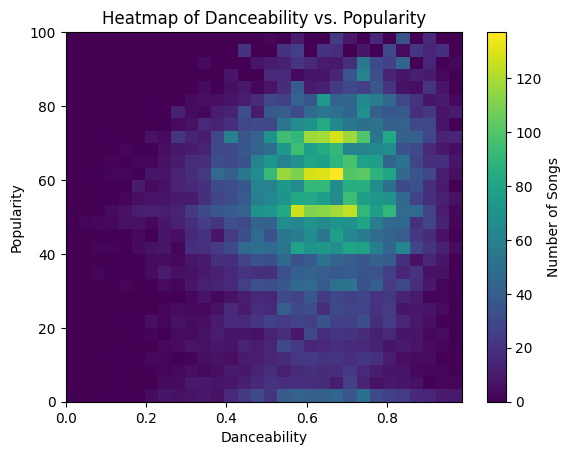

In [35]:
plt.hist2d(df['danceability'], df['song_popularity'], bins=[30, 30], cmap='viridis')
plt.colorbar(label='Number of Songs')
plt.xlabel('Danceability')
plt.ylabel('Popularity')
plt.title('Heatmap of Danceability vs. Popularity')

The heat map above reflects that there are a high volume of songs that are more danceable (around 0.5-0.7) and they are scaled between 40-80 on the popularity scale. This may indicate that songs with a danceable attribute are moderately to highly popular amongst listeners.

**Popularity by Tempo Range**





In [36]:
#create simple tempo bins
tempo_bins = [0, 80, 120, 160, 300]  # slow, medium, fast, very fast
tempo_labels = ['Slow', 'Medium', 'Fast', 'Very Fast']
df['tempo_range'] = pd.cut(df['tempo'], bins=tempo_bins, labels=tempo_labels, include_lowest=True)

#group by tempo range
summary_tempo = df.groupby('tempo_range').agg(
    count=('song_popularity', 'size'),
    avg_popularity=('song_popularity', 'mean')
)

print(summary_tempo)


             count  avg_popularity
tempo_range                       
Slow          1087       51.786569
Medium        8266       53.771594
Fast          7427       52.537768
Very Fast     2055       52.134307


/tmp/ipython-input-3221680149.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_tempo = df.groupby('tempo_range').agg(


We divided up the songs into 4 different tempos: Slow, Medium, Fast, and Very Fast. The results show that medium-tempo songs are both the most common and have the highest average popularity. Slow and very fast songs are less frequent and slightly less popular on average. This show us that that songs with a more moderate tempo tend to be more popular.

**Next Steps:** Using our research we hope to be able to expand this analysis to include more broad genre-based comparisons and predict future streaming performances using a regression model from the combined datasets.

In [37]:

%%shell
jupyter nbconvert --to html "/content/drive/MyDrive/Data_Science_Project.ipynb"


[NbConvertApp] Converting notebook /content/drive/MyDrive/Data_Science_Project.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 363754 bytes to /content/drive/MyDrive/Data_Science_Project.html
